# Synthetic Overlap Classifier Dataset

Builds a binary dataset for detecting whether a patch contains one spot or two overlapping spots.

- `label = 0`: one real source spot, centered in the patch
- `label = 1`: two source spots synthetically overlapped

The source files are read from `../data_esrf/output`. The class imbalance is controlled with `NEGATIVE_TO_POSITIVE_RATIO`, so `50` means roughly one overlapped sample for every fifty single-spot samples.

In [ ]:
from contextlib import contextmanager
from pathlib import Path
import json
import zlib

import h5py
import hdf5plugin  # noqa: F401 - registers source-file compression filters
import matplotlib.pyplot as plt
import numpy as np


def find_project_dir():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "train.py").exists() and (candidate / "augment_data").exists():
            return candidate
    raise RuntimeError("Could not find the project directory containing train.py.")


PROJECT_DIR = find_project_dir()
SOURCE_DIR = PROJECT_DIR.parent / "data_esrf" / "output"
TRAIN_FILE = PROJECT_DIR.parent / "data_esrf" / "overlap_classifier_train.h5"
VALIDATION_FILE = PROJECT_DIR.parent / "data_esrf" / "overlap_classifier_validation.h5"
PREVIEW_FILE = PROJECT_DIR / "augment_data" / "overlap_classifier_preview.png"

TOTAL_SAMPLES = 100_000
VALIDATION_FRACTION = 0.20
NEGATIVE_TO_POSITIVE_RATIO = 50  # 50 -> about 1 positive overlap per 50 normal spots; use 100 for 1:100.
FIXED_PATCH_SHAPE = (128, 128)
PATCH_MARGIN = 8
OVERLAP_RANGE = (0.10, 0.90)
ROTATION_RANGE = (0.0, 360.0)
ALLOW_FLIPS = True
LAYOUT_ATTEMPTS = 64
MAX_SAMPLE_ATTEMPTS = 64
RNG_SEED = 11
OVERWRITE = False
RUN_FULL_GENERATION = False

SOURCE_FILES = sorted(SOURCE_DIR.glob("*.h5"))
if not SOURCE_FILES:
    raise FileNotFoundError(f"No HDF5 files found in {SOURCE_DIR}")

print(f"Sources:    {SOURCE_DIR}")
print(f"Train:      {TRAIN_FILE}")
print(f"Validation: {VALIDATION_FILE}")
print(f"Experiments ({len(SOURCE_FILES)}):")
for source in SOURCE_FILES:
    print("  ", source.name)

Sources:    /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/output
Train:      /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/overlap_classifier_train.h5
Validation: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/overlap_classifier_validation.h5
Experiments (9):
   Al_big_grains_logtif.h5
   Al_deformed_LoG_logtif.h5
   Al_segvol.h5
   Al_small_grains_logtif.h5
   Cu_logtif.h5
   IN718_twins_logtif.h5
   Iron_deformed_logtif.h5
   Iron_logtif.h5
   Ti7Al_logtif.h5


In [2]:
def find_spot_group(h5_file):
    for candidate in ("im_seg/spots", "segvol/spots"):
        if candidate in h5_file:
            return candidate
    raise KeyError("Neither im_seg/spots nor segvol/spots exists")


def tight_slices(mask, margin=0):
    rows, cols = np.where(mask)
    if rows.size == 0:
        raise ValueError("Cannot crop an empty mask")
    r0 = max(int(rows.min()) - margin, 0)
    c0 = max(int(cols.min()) - margin, 0)
    r1 = min(int(rows.max()) + margin + 1, mask.shape[0])
    c1 = min(int(cols.max()) + margin + 1, mask.shape[1])
    return slice(r0, r1), slice(c0, c1)


class SpotArchive:
    def __init__(self, path, seed=RNG_SEED, validation_fraction=VALIDATION_FRACTION):
        self.path = Path(path)
        self.name = self.path.stem
        self._h5 = None

        with h5py.File(self.path, "r") as f:
            self.group_path = find_spot_group(f)
            group = f[self.group_path]
            self.blob_id = group["blob_id"][:]
            self.frame_idx = group["frame_idx"][:]
            self.partner_blob_id = group["friedel_partner_id"][:] if "friedel_partner_id" in group else np.full(len(self.blob_id), -1)
            self.offset = group["offset"][:]
            self.shape = group["shape"][:]
            self.ncc_score = group["ncc_score"][:] if "ncc_score" in group else np.full(len(self.blob_id), np.nan)

        self.n_spots = len(self.blob_id)
        lookup = {int(blob): row for row, blob in enumerate(self.blob_id)}
        self.partner_row = np.array([lookup.get(int(partner), -1) for partner in self.partner_blob_id], dtype=np.int64)

        rows = np.arange(self.n_spots, dtype=np.int64)
        resolved = self.partner_row >= 0
        self.donor_group = rows.copy()
        self.donor_group[resolved] = np.minimum(rows[resolved], self.partner_row[resolved])
        groups = np.unique(self.donor_group)

        stable_seed = int(seed) + zlib.crc32(self.name.encode("utf-8"))
        rng = np.random.default_rng(stable_seed)
        shuffled_groups = groups.copy()
        rng.shuffle(shuffled_groups)
        n_validation = int(round(len(groups) * validation_fraction))
        n_validation = min(max(n_validation, 1), len(groups) - 1)
        validation_groups = set(map(int, shuffled_groups[:n_validation]))
        is_validation = np.fromiter((int(group) in validation_groups for group in self.donor_group), dtype=bool, count=self.n_spots)

        self.rows = {"train": rows[~is_validation], "validation": rows[is_validation]}
        self.groups = {split: np.unique(self.donor_group[split_rows]) for split, split_rows in self.rows.items()}

    def open(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.path, "r")
        return self

    def close(self):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    def read_spot(self, row, margin=PATCH_MARGIN):
        self.open()
        row = int(row)
        height, width = map(int, self.shape[row])
        start = int(self.offset[row])
        stop = start + height * width
        group = self._h5[self.group_path]
        patch = group["patches"][start:stop].reshape(height, width).astype(np.float32)
        mask = group["masks"][start:stop].reshape(height, width).astype(bool)
        if not mask.any():
            raise ValueError(f"Empty mask in {self.name}, row {row}")

        background = patch[~mask]
        local_background = float(np.median(background)) if background.size else 0.0
        signal = patch - local_background
        signal[~mask] = 0.0
        signal[~np.isfinite(signal)] = 0.0
        np.maximum(signal, 0.0, out=signal)

        rr, cc = tight_slices(mask, margin=margin)
        return {
            "experiment": self.name,
            "source_file": self.path.name,
            "row": row,
            "blob_id": int(self.blob_id[row]),
            "frame": int(self.frame_idx[row]),
            "donor_group": int(self.donor_group[row]),
            "ncc": float(self.ncc_score[row]),
            "image": np.ascontiguousarray(signal[rr, cc]),
            "mask": np.ascontiguousarray(mask[rr, cc]),
        }


@contextmanager
def opened_archives(archives):
    try:
        for archive in archives:
            archive.open()
        yield archives
    finally:
        for archive in archives:
            archive.close()


ARCHIVES = [SpotArchive(path) for path in SOURCE_FILES]
experiment_names = [archive.name for archive in ARCHIVES]

print(f"{'experiment':38s} {'spots':>9s} {'groups':>9s} {'train rows':>11s} {'val rows':>9s}")
for archive in ARCHIVES:
    print(f"{archive.name:38s} {archive.n_spots:9,d} {len(np.unique(archive.donor_group)):9,d} {len(archive.rows['train']):11,d} {len(archive.rows['validation']):9,d}")

for archive in ARCHIVES:
    assert not np.intersect1d(archive.rows["train"], archive.rows["validation"]).size
    assert not np.intersect1d(archive.groups["train"], archive.groups["validation"]).size
print("\nAll source splits are donor-disjoint and keep Friedel partners together when partner ids are available.")

experiment                                 spots    groups  train rows  val rows
Al_big_grains_logtif                       9,888     4,944       7,910     1,978
Al_deformed_LoG_logtif                        68        34          54        14
Al_segvol                                 14,064     7,032      11,252     2,812
Al_small_grains_logtif                   204,946   102,473     163,956    40,990
Cu_logtif                                 39,730    19,865      31,784     7,946
IN718_twins_logtif                         2,754     1,377       2,204       550
Iron_deformed_logtif                         560       280         448       112
Iron_logtif                               15,394     7,697      12,316     3,078
Ti7Al_logtif                               1,964       982       1,572       392

All source splits are donor-disjoint and keep Friedel partners together when partner ids are available.


In [ ]:
def rotate_image_and_mask(image, mask, angle_degrees):
    angle = np.deg2rad(angle_degrees)
    cos_a, sin_a = float(np.cos(angle)), float(np.sin(angle))
    height, width = image.shape
    corners = np.array([[0, 0], [0, width - 14kV)dJQCbbUL], [height - 1, 0], [height - 1, width - 1]], dtype=np.float32)
    center = np.array([(height - 1) / 2, (width - 1) / 2], dtype=np.float32)
    relative = corners - center
    rotated = np.column_stack([relative[:, 0] * cos_a - relative[:, 1] * sin_a, relative[:, 0] * sin_a + relative[:, 1] * cos_a])
    minimum = np.floor(rotated.min(axis=0))
    maximum = np.ceil(rotated.max(axis=0))
    out_height, out_width = (maximum - minimum + 1).astype(int)

    out_rows, out_cols = np.indices((out_height, out_width), dtype=np.float32)
    relative_rows = out_rows + minimum[0]
    relative_cols = out_cols + minimum[1]
    source_rows = relative_rows * cos_a + relative_cols * sin_a + center[0]
    source_cols = -relative_rows * sin_a + relative_cols * cos_a + center[1]

    nearest_rows = np.rint(source_rows).astype(np.int32)
    nearest_cols = np.rint(source_cols).astype(np.int32)
    nearest_valid = (nearest_rows >= 0) & (nearest_rows < height) & (nearest_cols >= 0) & (nearest_cols < width)
    rotated_mask = np.zeros((out_height, out_width), dtype=bool)
    rotated_mask[nearest_valid] = mask[nearest_rows[nearest_valid], nearest_cols[nearest_valid]]

    r0 = np.floor(source_rows).astype(np.int32)
    c0 = np.floor(source_cols).astype(np.int32)
    r1, c1 = r0 + 1, c0 + 1
    linear_valid = (r0 >= 0) & (r1 < height) & (c0 >= 0) & (c1 < width)
    dr, dc = source_rows - r0, source_cols - c0
    rotated_image = np.zeros((out_height, out_width), dtype=np.float32)
    rotated_image[linear_valid] = (
        image[r0[linear_valid], c0[linear_valid]] * (1 - dr[linear_valid]) * (1 - dc[linear_valid])
        + image[r1[linear_valid], c0[linear_valid]] * dr[linear_valid] * (1 - dc[linear_valid])
        + image[r0[linear_valid], c1[linear_valid]] * (1 - dr[linear_valid]) * dc[linear_valid]
        + image[r1[linear_valid], c1[linear_valid]] * dr[linear_valid] * dc[linear_valid]
    )
    return rotated_image, rotated_mask


def random_variant(spot, rng):
    image, mask = spot["image"], spot["mask"]
    flip_ud = bool(ALLOW_FLIPS and rng.integers(0, 2))
    flip_lr = bool(ALLOW_FLIPS and rng.integers(0, 2))
    angle = float(rng.uniform(*ROTATION_RANGE))
    if flip_ud:
        image, mask = np.flipud(image), np.flipud(mask)
    if flip_lr:
        image, mask = np.fliplr(image), np.fliplr(mask)

    image, mask = rotate_image_and_mask(image, mask, angle)
    if not mask.any():
        raise ValueError("Rotation produced an empty mask")
    rr, cc = tight_slices(mask)
    image = np.ascontiguousarray(image[rr, cc], dtype=np.float32)
    mask = np.ascontiguousarray(mask[rr, cc], dtype=bool)
    image[~mask] = 0.0
    return {**{key: spot[key] for key in ("experiment", "source_file", "row", "blob_id", "frame", "donor_group", "ncc")}, "image": image, "mask": mask, "flip_ud": flip_ud, "flip_lr": flip_lr, "angle_degrees": angle}


def center_pad(array, target_shape=FIXED_PATCH_SHAPE):
    target_height, target_width = target_shape
    *leading, height, width = array.shape
    if height > target_height or width > target_width:
        raise ValueError(f"Array {array.shape} does not fit target {target_shape}")
    output = np.zeros((*leading, target_height, target_width), dtype=array.dtype)
    top, left = (target_height - height) // 2, (target_width - width) // 2
    output[..., top:top + height, left:left + width] = array
    return output, (top, left)


def overlap_for_offset(left_mask, right_mask, right_top, right_left):
    left_height, left_width = left_mask.shape
    right_height, right_width = right_mask.shape
    lr0, lc0 = max(0, right_top), max(0, right_left)
    lr1 = min(left_height, right_top + right_height)
    lc1 = min(left_width, right_left + right_width)
    if lr1 <= lr0 or lc1 <= lc0:
        return 0.0
    rr0, rc0 = lr0 - right_top, lc0 - right_left
    rr1, rc1 = rr0 + (lr1 - lr0), rc0 + (lc1 - lc0)
    overlap = np.logical_and(left_mask[lr0:lr1, lc0:lc1], right_mask[rr0:rr1, rc0:rc1]).sum()
    return float(overlap / max(min(left_mask.sum(), right_mask.sum()), 1))


def positive_layout(left_shape, right_shape, right_top, right_left):
    left_height, left_width = left_shape
    right_height, right_width = right_shape
    origin_top, origin_left = min(0, right_top), min(0, right_left)
    left_top, left_left = -origin_top, -origin_left
    right_top, right_left = right_top - origin_top, right_left - origin_left
    canvas_height = max(left_top + left_height, right_top + right_height)
    canvas_width = max(left_left + left_width, right_left + right_width)
    return left_top, left_left, right_top, right_left, canvas_height, canvas_width


def random_pair_layout(left_mask, right_mask, requested_overlap, rng):
    left_height, left_width = left_mask.shape
    right_height, right_width = right_mask.shape
    requested_overlap = float(np.clip(requested_overlap, *OVERLAP_RANGE))
    overlap_height = max(1, int(round(min(left_height, right_height) * requested_overlap)))
    overlap_width = max(1, int(round(min(left_width, right_width) * requested_overlap)))
    candidates = [
        (left_height - overlap_height, left_width - overlap_width),
        (left_height - overlap_height, -(right_width - overlap_width)),
        (-(right_height - overlap_height), left_width - overlap_width),
        (-(right_height - overlap_height), -(right_width - overlap_width)),
        ((left_height - right_height) // 2, (left_width - right_width) // 2),
    ]
    for _ in range(LAYOUT_ATTEMPTS):
        candidates.append((int(rng.integers(-right_height + 1, left_height)), int(rng.integers(-right_width + 1, left_width))))

    best = None
    for right_top, right_left in candidates:
        layout = positive_layout(left_mask.shape, right_mask.shape, right_top, right_left)
        if layout[4] > FIXED_PATCH_SHAPE[0] or layout[5] > FIXED_PATCH_SHAPE[1]:
            continue
        measured = overlap_for_offset(left_mask, right_mask, right_top, right_left)
        range_penalty = 0 if OVERLAP_RANGE[0] <= measured <= OVERLAP_RANGE[1] else 1
        score = (range_penalty, abs(measured - requested_overlap), -measured)
        if best is None or score < best[0]:
            best = (score, layout, measured)
    if best is None:
        raise ValueError("No complete pair layout fits the fixed canvas")
    return (*best[1], float(best[2]))


def paste_channel(channel, mask_channel, variant, top, left):
    height, width = variant["mask"].shape
    channel[top:top + height, left:left + width][variant["mask"]] = variant["image"][variant["mask"]]
    mask_channel[top:top + height, left:left + width][variant["mask"]] = 1
    return [int(top), int(left), int(top + height), int(left + width)]

In [4]:
def stable_rng(archive_name, split, label, seed=RNG_SEED):
    token = f"{archive_name}:{split}:{label}".encode("utf-8")
    return np.random.default_rng(int(seed) + zlib.crc32(token))


def choose_one_donor(archive, split, rng):
    return int(rng.choice(archive.rows[split]))


def choose_two_donors(archive, split, rng):
    rows = archive.rows[split]
    if len(archive.groups[split]) < 2:
        raise ValueError(f"{archive.name}/{split} has fewer than two independent donor groups")
    for _ in range(100):
        left_row, right_row = map(int, rng.choice(rows, size=2, replace=False))
        if archive.donor_group[left_row] != archive.donor_group[right_row]:
            return left_row, right_row
    raise RuntimeError(f"Could not draw two independent donors from {archive.name}/{split}")


def make_single_sample(archive, split, rng):
    for _ in range(MAX_SAMPLE_ATTEMPTS):
        try:
            row = choose_one_donor(archive, split, rng)
            variant = random_variant(archive.read_spot(row), rng)
            image, pad = center_pad(variant["image"])
            mask, _ = center_pad(variant["mask"].astype(np.uint8))
            metadata = {
                "experiment": archive.name,
                "split": split,
                "label": 0,
                "measured_overlap_fraction": 0.0,
                "padding_top_left": [int(pad[0]), int(pad[1])],
                "donors": [{
                    "source_file": variant["source_file"],
                    "source_row": int(variant["row"]),
                    "blob_id": int(variant["blob_id"]),
                    "frame": int(variant["frame"]),
                    "donor_group": int(variant["donor_group"]),
                    "ncc": float(variant["ncc"]),
                    "flip_ud": bool(variant["flip_ud"]),
                    "flip_lr": bool(variant["flip_lr"]),
                    "angle_degrees": float(variant["angle_degrees"]),
                }],
            }
            return image.astype(np.float32), mask.astype(np.uint8), metadata
        except (ValueError, RuntimeError):
            continue
    raise RuntimeError(f"Failed to make a single-spot sample for {archive.name}/{split}")


def make_overlap_sample(archive, split, rng):
    for _ in range(MAX_SAMPLE_ATTEMPTS):
        try:
            left_row, right_row = choose_two_donors(archive, split, rng)
            left = random_variant(archive.read_spot(left_row), rng)
            right = random_variant(archive.read_spot(right_row), rng)
            requested = float(rng.uniform(*OVERLAP_RANGE))
            layout = random_pair_layout(left["mask"], right["mask"], requested, rng)
            left_top, left_left, right_top, right_left, height, width, measured = layout

            spot_images = np.zeros((2, height, width), dtype=np.float32)
            spot_masks = np.zeros((2, height, width), dtype=np.uint8)
            left_bbox = paste_channel(spot_images[0], spot_masks[0], left, left_top, left_left)
            right_bbox = paste_channel(spot_images[1], spot_masks[1], right, right_top, right_left)
            spot_images, pad = center_pad(spot_images)
            spot_masks, _ = center_pad(spot_masks)
            image = spot_images.sum(axis=0, dtype=np.float32)
            union_mask = np.clip(spot_masks.sum(axis=0), 0, 1).astype(np.uint8)

            donors = []
            for variant, bbox in ((left, left_bbox), (right, right_bbox)):
                donors.append({
                    "source_file": variant["source_file"],
                    "source_row": int(variant["row"]),
                    "blob_id": int(variant["blob_id"]),
                    "frame": int(variant["frame"]),
                    "donor_group": int(variant["donor_group"]),
                    "ncc": float(variant["ncc"]),
                    "flip_ud": bool(variant["flip_ud"]),
                    "flip_lr": bool(variant["flip_lr"]),
                    "angle_degrees": float(variant["angle_degrees"]),
                    "paste_bbox_before_padding": bbox,
                })

            metadata = {
                "experiment": archive.name,
                "split": split,
                "label": 1,
                "requested_overlap_fraction": requested,
                "measured_overlap_fraction": measured,
                "canvas_shape_before_padding": [int(height), int(width)],
                "padding_top_left": [int(pad[0]), int(pad[1])],
                "donors": donors,
            }
            return image.astype(np.float32), union_mask, metadata
        except (ValueError, RuntimeError):
            continue
    raise RuntimeError(f"Failed to make an overlap sample for {archive.name}/{split}")

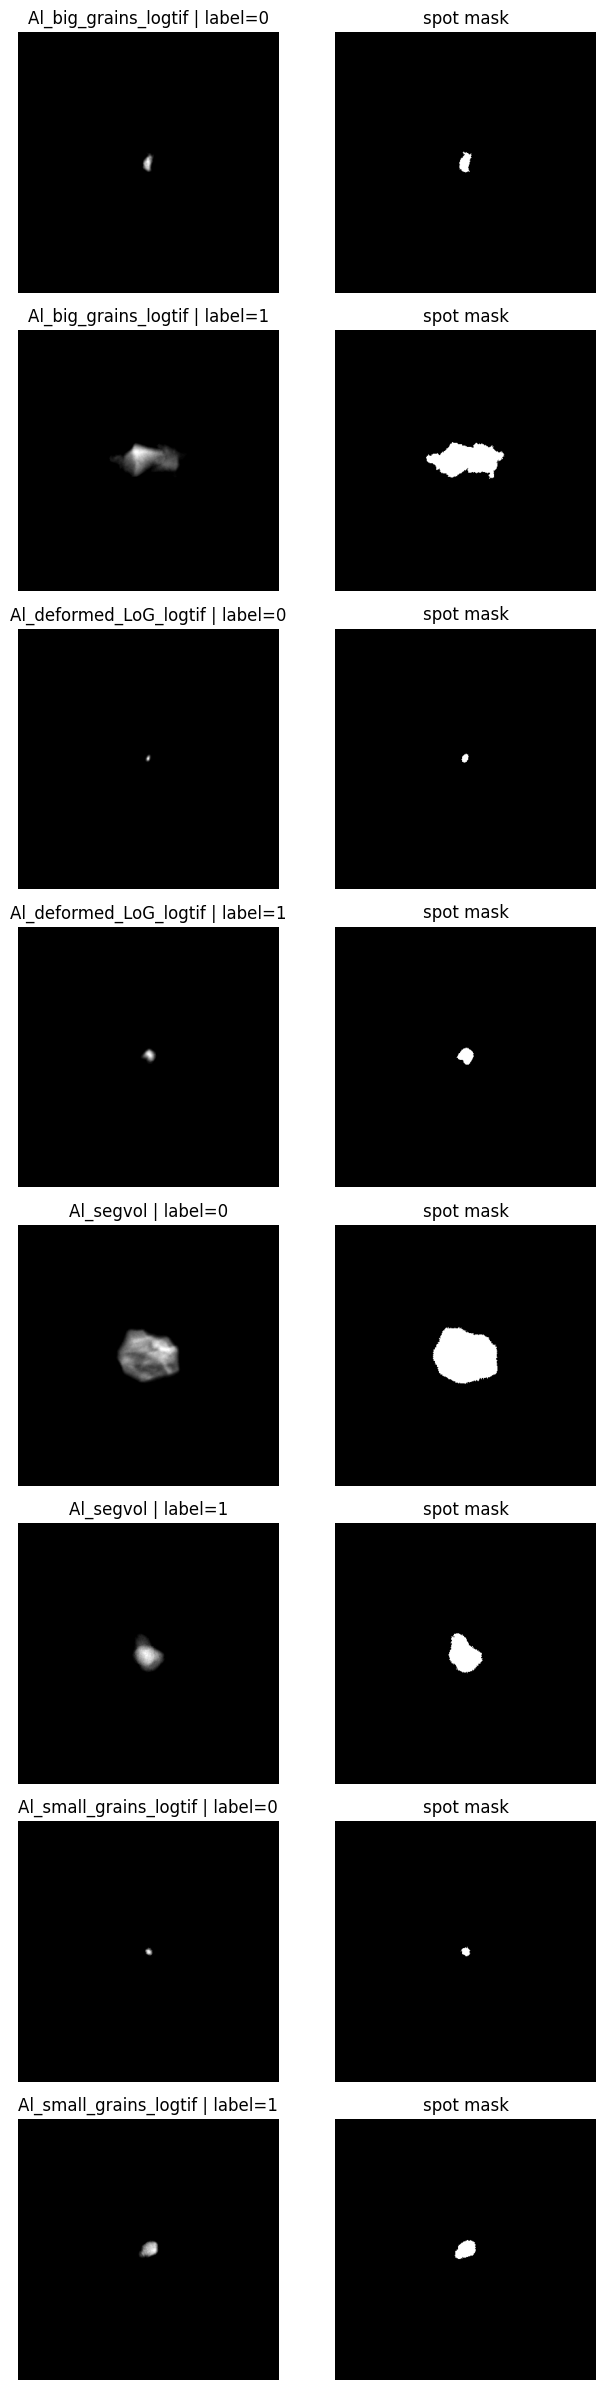

Saved preview to /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/augment_data/overlap_classifier_preview.png


In [5]:
def robust_limits(array, lower=1, upper=99.8):
    values = np.asarray(array)
    values = values[np.isfinite(values) & (values > 0)]
    if values.size == 0:
        return 0.0, 1.0
    low, high = np.percentile(values, [lower, upper])
    return float(low), float(max(high, low + 1e-6))


preview = []
with opened_archives(ARCHIVES):
    for archive in ARCHIVES[: min(4, len(ARCHIVES))]:
        single_rng = stable_rng(archive.name, "train", "single_preview")
        overlap_rng = stable_rng(archive.name, "train", "overlap_preview")
        preview.append((archive.name, make_single_sample(archive, "train", single_rng)))
        preview.append((archive.name, make_overlap_sample(archive, "train", overlap_rng)))

fig, axes = plt.subplots(len(preview), 2, figsize=(7, 3 * len(preview)), squeeze=False)
for row, (experiment, sample) in enumerate(preview):
    image, mask, metadata = sample
    low, high = robust_limits(image)
    axes[row, 0].imshow(image, cmap="gray", vmin=low, vmax=high)
    axes[row, 0].set_title(f"{experiment} | label={metadata['label']}")
    axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("spot mask")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
fig.savefig(PREVIEW_FILE, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved preview to {PREVIEW_FILE}")

In [ ]:
def split_class_counts(total, negative_to_positive_ratio):
    positives = max(1, int(round(total / (negative_to_positive_ratio + 1))))
    negatives = int(total) - positives
    return {0: negatives, 1: positives}


def allocate_evenly(total, names):
    names = list(names)
    base, remainder = divmod(int(total), len(names))
    return {name: base + int(index < remainder) for index, name in enumerate(names)}


validation_total = int(round(TOTAL_SAMPLES * VALIDATION_FRACTION))
train_total = TOTAL_SAMPLES - validation_total
TRAIN_CLASS_COUNTS = split_class_counts(train_total, NEGATIVE_TO_POSITIVE_RATIO)
VALIDATION_CLASS_COUNTS = split_class_counts(validation_total, NEGATIVE_TO_POSITIVE_RATIO)
TRAIN_QUOTAS = {label: allocate_evenly(count, experiment_names) for label, count in TRAIN_CLASS_COUNTS.items()}
VALIDATION_QUOTAS = {label: allocate_evenly(count, experiment_names) for label, count in VALIDATION_CLASS_COUNTS.items()}

print(f"Requested total: {TOTAL_SAMPLES:,}")
for split, counts in (("train", TRAIN_CLASS_COUNTS), ("validation", VALIDATION_CLASS_COUNTS)):
    print(f"\n{split}: {sum(counts.values()):,} samples")
    print(f"  label 0 single:  {counts[0]:,}")
    print(f"  label 1 overlap: {counts[1]:,}")
    print(f"  effective negative:positive = {counts[0] / counts[1]:.1f}:1")

In [ ]:
def initialize_output(h5_file, split, class_counts, quotas):
    total = sum(class_counts.values())
    h5_file.attrs.update({
        "format": "spot_overlap_binary_classifier",
        "label_0": "single_spot",
        "label_1": "synthetic_overlap",
        "split": split,
        "seed": RNG_SEED,
        "fixed_patch_shape": json.dumps(list(FIXED_PATCH_SHAPE)),
        "negative_to_positive_ratio": NEGATIVE_TO_POSITIVE_RATIO,
        "overlap_range": json.dumps(list(OVERLAP_RANGE)),
        "rotation_range_degrees": json.dumps(list(ROTATION_RANGE)),
        "source_directory": str(SOURCE_DIR),
        "experiments": json.dumps(experiment_names),
        "class_counts": json.dumps(class_counts),
        "sample_quotas": json.dumps(quotas),
        "friedel_split_policy": "both members kept in same source split when partner ids are available",
    })
    h5_file.create_dataset("images", shape=(total, *FIXED_PATCH_SHAPE), dtype=np.float32, chunks=(1, *FIXED_PATCH_SHAPE), compression="gzip", compression_opts=4)
    h5_file.create_dataset("masks", shape=(total, *FIXED_PATCH_SHAPE), dtype=np.uint8, chunks=(1, *FIXED_PATCH_SHAPE), compression="gzip", compression_opts=4)
    h5_file.create_dataset("labels", shape=(total,), dtype=np.uint8)
    h5_file.create_dataset("experiment_index", shape=(total,), dtype=np.int16)
    h5_file.create_dataset("source_rows", shape=(total, 2), dtype=np.int32)
    h5_file.create_dataset("source_blob_ids", shape=(total, 2), dtype=np.int32)
    h5_file.create_dataset("source_donor_groups", shape=(total, 2), dtype=np.int32)
    h5_file.create_dataset("measured_overlap", shape=(total,), dtype=np.float32)

    source_splits = h5_file.create_group("source_splits")
    for archive in ARCHIVES:
        group = source_splits.create_group(archive.name)
        group.create_dataset("rows", data=archive.rows[split], compression="gzip")
        group.create_dataset("donor_groups", data=archive.groups[split], compression="gzip")


def write_example(output, index, experiment_index, label, image, mask, metadata):
    donors = metadata["donors"]
    rows = [int(donor["source_row"]) for donor in donors]
    blobs = [int(donor["blob_id"]) for donor in donors]
    groups = [int(donor["donor_group"]) for donor in donors]
    while len(rows) < 2:
        rows.append(-1)
        blobs.append(-1)
        groups.append(-1)

    output["images"][index] = image
    output["masks"][index] = mask
    output["labels"][index] = int(label)
    output["experiment_index"][index] = int(experiment_index)
    output["source_rows"][index] = rows[:2]
    output["source_blob_ids"][index] = blobs[:2]
    output["source_donor_groups"][index] = groups[:2]
    output["measured_overlap"][index] = float(metadata.get("measured_overlap_fraction", 0.0))


def shuffled_plan(quotas, split):
    entries = []
    for label, by_experiment in quotas.items():
        for experiment_index, archive in enumerate(ARCHIVES):
            entries.extend([(int(label), experiment_index)] * int(by_experiment[archive.name]))
    rng = np.random.default_rng(RNG_SEED + zlib.crc32(f"plan:{split}".encode("utf-8")))
    rng.shuffle(entries)
    return entries


def write_split_to_temp(path, split, class_counts, quotas):
    temporary = path.with_name(f"{path.stem}.tmp{path.suffix}")
    if temporary.exists():
        temporary.unlink()
    plan = shuffled_plan(quotas, split)
    rngs = {(archive.name, label): stable_rng(archive.name, split, f"label_{label}") for archive in ARCHIVES for label in (0, 1)}

    with h5py.File(temporary, "w") as output:
        initialize_output(output, split, class_counts, quotas)
        with opened_archives(ARCHIVES):
            for sample_index, (label, experiment_index) in enumerate(plan):
                archive = ARCHIVES[experiment_index]
                rng = rngs[(archive.name, label)]
                if label == 0:
                    image, mask, metadata = make_single_sample(archive, split, rng)
                else:
                    image, mask, metadata = make_overlap_sample(archive, split, rng)
                write_example(output, sample_index, experiment_index, label, image, mask, metadata)
                if (sample_index + 1) % 1000 == 0:
                    output.flush()
                    print(f"{split:10s} wrote {sample_index + 1:,}/{len(plan):,}")
    return temporary


def write_classifier_archives(overwrite=OVERWRITE):
    for path in (TRAIN_FILE, VALIDATION_FILE):
        if path.exists() and not overwrite:
            raise FileExistsError(f"{path} exists. Set OVERWRITE=True to replace it.")
    train_temp = validation_temp = None
    try:
        train_temp = write_split_to_temp(TRAIN_FILE, "train", TRAIN_CLASS_COUNTS, TRAIN_QUOTAS)
        validation_temp = write_split_to_temp(VALIDATION_FILE, "validation", VALIDATION_CLASS_COUNTS, VALIDATION_QUOTAS)
        train_temp.replace(TRAIN_FILE)
        validation_temp.replace(VALIDATION_FILE)
    except Exception:
        for temporary in (train_temp, validation_temp):
            if temporary is not None and temporary.exists():
                temporary.unlink()
        raise
    print(f"Wrote {TRAIN_FILE}")
    print(f"Wrote {VALIDATION_FILE}")

In [ ]:
def validate_classifier_archives(train_file=TRAIN_FILE, validation_file=VALIDATION_FILE, checks_per_file=20):
    for path in (train_file, validation_file):
        if not Path(path).exists():
            print(f"Not generated yet: {path}")
            return False

    donor_sets = {}
    for split, path in (("train", train_file), ("validation", validation_file)):
        with h5py.File(path, "r") as f:
            labels = f["labels"][:]
            rows = f["source_rows"][:]
            experiments = f["experiment_index"][:]
            print(f"\n{split}: {len(labels):,} samples")
            for label, name in ((0, "single"), (1, "overlap")):
                print(f"  label {label} {name:7s}: {int((labels == label).sum()):,}")

            keys = set()
            for experiment, pair in zip(experiments, rows):
                for row in pair:
                    if row >= 0:
                        keys.add((int(experiment), int(row)))
            donor_sets[split] = keys

            indices = np.linspace(0, len(labels) - 1, min(checks_per_file, len(labels)), dtype=int)
            for index in indices:
                image = f["images"][index]
                mask = f["masks"][index]
                assert image.shape == FIXED_PATCH_SHAPE
                assert mask.shape == FIXED_PATCH_SHAPE
                assert labels[index] in (0, 1)
                assert set(np.unique(mask)).issubset({0, 1})
                assert np.all(np.isfinite(image))
                assert image.max() >= 0
                if labels[index] == 0:
                    assert rows[index, 1] == -1
                else:
                    assert rows[index, 0] != rows[index, 1]
                    assert f["measured_overlap"][index] >= 0

    leakage = donor_sets["train"] & donor_sets["validation"]
    assert not leakage, f"Found {len(leakage)} source donors in both files"
    print("\nValidation passed: shapes, labels, masks, class counts, and donor isolation are correct.")
    return True


if RUN_FULL_GENERATION:
    write_classifier_archives(overwrite=OVERWRITE)
    validate_classifier_archives()
else:
    print("Preview complete. Set RUN_FULL_GENERATION = True to create the classifier archives.")